In [193]:
import os
import re
import pandas as pd
import glob
from dotenv import load_dotenv
import requests
from functools import reduce
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from tabulate import tabulate

In [194]:
geocodes = pd.read_excel("all-geocodes-v2020.xlsx", skiprows = 4, dtype = str)

In [195]:
geocodes = geocodes[geocodes["State Code (FIPS)"] == "06"]

In [196]:
geocodes = geocodes.rename(columns = {"Area Name (including legal/statistical area description)": "CountyName"})

## Census Demographic Census Data from 2023

In [197]:
user = os.path.expanduser("~")

In [198]:
load_dotenv(os.path.join(user, "Documents", ".env"))

False

In [199]:
key = os.getenv("CENSUS_API_KEY")

In [200]:
url = "https://api.census.gov/data/2023/acs/acs5"

In [201]:
vars = [
    "NAME",
    "B01003_001E",
    "B01001_001E",
    "B02001_001E",
    "B03003_003E",
    "B19013_001E",
    "B15003_022E",
    "B15003_023E",
    "B15003_024E",
    "B15003_025E",
    "B23025_003E",
    "B23025_005E",
    "B25064_001E",
    "B25077_001E",
    "B07001_017E",
    "B07001_081E",
    "B07001_085E",
    "B25003_002E",
    "B25003_003E"
]

In [202]:
params = {"get" : ",".join(vars), "for" : "county:*"}

In [203]:
response = requests.get(url, params = params)

In [204]:
demographics = pd.DataFrame(response.json()[1:], columns = response.json()[0])

In [205]:
rename_map = {
    "NAME": "CountyName",
    "B01003_001E": "total_population",
    "B01001_001E": "total_age_population",
    "B02001_001E": "total_race_population",
    "B03003_003E": "hispanic_or_latino",
    "B19013_001E": "median_household_income",
    "B15003_022E": "bachelors_degree",
    "B15003_023E": "masters_degree",
    "B15003_024E": "professional_degree",
    "B15003_025E": "doctorate_degree",
    "B23025_003E": "labor_force",
    "B23025_005E": "unemployed",
    "B25064_001E": "median_rent",
    "B25077_001E": "median_home_value",
    "B07001_017E": "same_house_1yr_ago",
    "B07001_081E": "moved_from_same_state",
    "B07001_085E": "moved_from_different_state",
    "B25003_002E": "owner_occupied",
    "B25003_003E": "renter_occupied",
    "state": "state_fips",
    "county": "county_fips"
}

demographics = demographics.rename(columns = rename_map)

In [206]:
print(demographics.head(10))

                 CountyName total_population total_age_population  \
0   Autauga County, Alabama            59285                59285   
1   Baldwin County, Alabama           239945               239945   
2   Barbour County, Alabama            24757                24757   
3      Bibb County, Alabama            22152                22152   
4    Blount County, Alabama            59292                59292   
5   Bullock County, Alabama            10157                10157   
6    Butler County, Alabama            18807                18807   
7   Calhoun County, Alabama           116141               116141   
8  Chambers County, Alabama            34450                34450   
9  Cherokee County, Alabama            25224                25224   

  total_race_population hispanic_or_latino median_household_income  \
0                 59285               2188                   69841   
1                239945              13393                   75019   
2                 24757       

In [207]:
demographics_2023_ca = demographics[demographics["CountyName"].str.endswith("California")]


In [208]:
print(demographics_2023_ca.head(10))

                          CountyName total_population total_age_population  \
187       Alameda County, California          1651949              1651949   
188        Alpine County, California             1695                 1695   
189        Amador County, California            41029                41029   
190         Butte County, California           209470               209470   
191     Calaveras County, California            45995                45995   
192        Colusa County, California            21895                21895   
193  Contra Costa County, California          1161458              1161458   
194     Del Norte County, California            27293                27293   
195     El Dorado County, California           192299               192299   
196        Fresno County, California          1012152              1012152   

    total_race_population hispanic_or_latino median_household_income  \
187               1651949             385245                  126240 

# Synthetic LODES (Where people live [RAC] vs where they work [WAC] | 2018 - 2022)

https://lehd.ces.census.gov/data/

https://www.census.gov/geographies/mapping-files/2024/geo/tiger-line-file.html

In [209]:
rac_files = glob.glob("ca_rac_S000_JT00_*.csv.gz")
wac_files = glob.glob("ca_wac_S000_JT00_*.csv.gz")

In [210]:
def read_lehd_file(file_path):
    # Extract year from filename
    year = int(os.path.basename(file_path).split("_")[-1].split(".")[0])
    
    # Read CSV (gzip compressed)
    df = pd.read_csv(file_path, dtype = {"h_geocode": str, "w_geocode": str})
    
    # Add year column
    df["year"] = year
    
    return df


In [211]:
rac_list = [read_lehd_file(f) for f in rac_files]
rac_df = pd.concat(rac_list, ignore_index=True)

In [212]:
wac_list = [read_lehd_file(f) for f in wac_files]
wac_df = pd.concat(wac_list, ignore_index=True)

In [213]:
rac_df["state_fips"] = rac_df["h_geocode"].str[:2] # first 2 digits = state
rac_df["county_fips"] = rac_df["h_geocode"].str[2:5] # next 3 digits = county
rac_df["county_fips"] = rac_df["state_fips"] + rac_df["county_fips"] # full 5-digit FIPS

In [214]:
wac_df["state_fips"] = wac_df["w_geocode"].str[:2] # first 2 digits = state
wac_df["county_fips"] = wac_df["w_geocode"].str[2:5] # next 3 digits = county
wac_df["county_fips"] = wac_df["state_fips"] + wac_df["county_fips"] # full 5-digit FIPS

In [215]:
rac_county = rac_df.groupby(["county_fips","year"])["C000"].sum().reset_index()
rac_county = rac_county.rename(columns = {"C000":"workers_living"})

In [216]:
wac_county = wac_df.groupby(["county_fips","year"])["C000"].sum().reset_index()
wac_county = wac_county.rename(columns = {"C000":"jobs_located"})

In [217]:
county_flow = rac_county.merge(wac_county, on = ["county_fips","year"])
county_flow["net_inflow"] = county_flow["jobs_located"] - county_flow["workers_living"]

In [218]:
county_flow["county_fips"] = county_flow["county_fips"].str[2:5]

In [219]:
county_flow = county_flow.merge(
    geocodes[["County Code (FIPS)", "CountyName"]],
    left_on = "county_fips",
    right_on = "County Code (FIPS)",
    how = "left"
)

In [220]:
county_flow

,county_fips,year,workers_living,jobs_located,net_inflow,County Code (FIPS),CountyName
0,001,2018,810472,813398,2926,001,Alameda County
1,001,2019,817258,807148,-10110,001,Alameda County
2,001,2020,767415,752402,-15013,001,Alameda County
3,001,2021,756046,767190,11144,001,Alameda County
4,001,2022,801985,819506,17521,001,Alameda County
...,...,...,...,...,...,...,...
285,115,2018,27305,15755,-11550,115,Yuba County
286,115,2019,27826,16194,-11632,115,Yuba County
287,115,2020,28849,16937,-11912,115,Yuba County
288,115,2021,29956,16404,-13552,115,Yuba County


In [221]:
county_flow_recent = county_flow[county_flow["year"] == 2022]
county_flow_recent = county_flow_recent.rename(columns = {"CountyName": "County"})
county_flow_recent["County"] = county_flow_recent["County"].str.removesuffix(" County")

In [222]:
print(county_flow_recent.head(10))

   county_fips  year  workers_living  jobs_located  net_inflow  \
4          001  2022          801985        819506       17521   
9          003  2022             926           260        -666   
14         005  2022           20524         12481       -8043   
19         007  2022           78666         74572       -4094   
24         009  2022           24504         10192      -14312   
29         011  2022            8900          8347        -553   
34         013  2022          523668        379038     -144630   
39         015  2022            9403          7564       -1839   
44         017  2022           83062         56088      -26974   
49         019  2022          404257        407174        2917   

   County Code (FIPS)        County  
4                 001       Alameda  
9                 003        Alpine  
14                005        Amador  
19                007         Butte  
24                009     Calaveras  
29                011        Colusa  
34     

# IRS Migration Data

https://www.irs.gov/statistics/soi-tax-stats-migration-data

In [223]:
irs_data_path = r"./Data"

In [224]:
csv_files = glob.glob(os.path.join(irs_data_path, "county*flow*.csv"))

In [225]:
irs_data = {}

for file in csv_files:
    fname = os.path.splitext(os.path.basename(file))[0]

    # get year portion from filename
    year_str = "20" + fname[-2:]
    
    df = pd.read_csv(file, dtype=str, encoding="latin1")

    # add a column for the year
    df["year_ending_in"] = year_str

    # add column for inflow/outflows
    if "inflow" in fname.lower():
        df["flow_type"] = "inflow"
    elif "outflow" in fname.lower():
        df["flow_type"] = "outflow"
    else:
        df["flow_type"] = "unknown"

    # save to dictionary
    irs_data[fname] = df

In [226]:
print(irs_data)

{'countyinflow1718':       y2_statefips y2_countyfips y1_statefips y1_countyfips y1_state  \
0               01           000           96           000       AL   
1               01           000           97           000       AL   
2               01           000           97           001       AL   
3               01           000           97           003       AL   
4               01           000           98           000       AL   
...            ...           ...          ...           ...      ...   
87927           56           045           59           000       DS   
87928           56           045           59           001       DS   
87929           56           045           59           003       DS   
87930           56           045           59           005       DS   
87931           56           045           59           007       DS   

                         y1_countyname      n1      n2      agi  \
0       Total Migration-US and Foreign  106934 

In [227]:
# combine into one data frame
irs_data_combined = pd.concat(irs_data.values(), ignore_index=True)

In [228]:
# some strings are incorrect (there exist some that are 06 or 6, which mean the same)
# coerce into ints to solve this problem
fips_colnames = ["y2_statefips", "y2_countyfips", "y1_statefips", "y1_countyfips"]
for col in fips_colnames:
    irs_data_combined[col] = pd.to_numeric(
        irs_data_combined[col]
    )

In [229]:
irs_ca = irs_data_combined[(irs_data_combined["y2_statefips"] == 6) | (irs_data_combined["y1_statefips"] == 6) ]

In [230]:
for col in ["n1", "n2", "agi", "year_ending_in"]:
    irs_ca[col] = pd.to_numeric(irs_ca[col])

C:\Users\jerem\AppData\Local\Temp\ipykernel_12312\3134775981.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  irs_ca[col] = pd.to_numeric(irs_ca[col])


In [231]:
# find inflow (where people move to California)
irs_in = irs_ca[(irs_ca["y2_statefips"] == 6) & (irs_ca["flow_type"] == "inflow")]
inflow = irs_in.groupby(["y2_countyfips", "year_ending_in"], as_index=False).agg({
    "n2": "sum",
    "agi": "sum"
}).rename(columns={"y2_countyfips": "countyfips", "n2": "total_inflow", "agi": "total_agi_in"})

In [232]:
# outflow (where people leave California)
irs_out = irs_ca[(irs_ca["y1_statefips"] == 6) & (irs_ca["flow_type"] == "outflow")]
outflow = irs_out.groupby(["y1_countyfips", "year_ending_in"], as_index=False).agg({
    "n1": "sum",
    "agi": "sum"
}).rename(columns={"y1_countyfips": "countyfips", "n1": "total_outflow", "agi": "total_agi_out"})

In [233]:
# merge inflow and outflow
county_migration = inflow.merge(outflow, on = ["countyfips", "year_ending_in"], how = "outer").fillna(0)

In [234]:
# find net migration
county_migration["net_migration"] = county_migration["total_inflow"] - county_migration["total_outflow"]
county_migration["net_agi"] = county_migration["total_agi_in"] - county_migration["total_agi_out"]

In [235]:
# repad zeros for countyfips
county_migration["countyfips"] = county_migration["countyfips"].astype(str).str.zfill(3)

In [309]:
print(county_migration.columns)

Index(['countyfips', 'year_ending_in', 'total_inflow', 'total_agi_in',
       'total_outflow', 'total_agi_out', 'net_migration', 'net_agi'],
      dtype='object')


In [312]:
print(county_migration[["total_outflow", "countyfips"]])

     total_outflow countyfips
0          2467112        000
1           821153        001
2           830426        001
3           852031        001
4           869946        001
..             ...        ...
286          33257        115
287          33807        115
288          35220        115
289          37714        115
290          39124        115

[291 rows x 2 columns]


In [313]:
print(county_migration[["total_inflow", "countyfips"]])

     total_inflow countyfips
0         4047935        000
1         1609930        001
2         1598822        001
3         1604170        001
4         1510297        001
..            ...        ...
286         79817        115
287         80167        115
288         87426        115
289         84656        115
290         86648        115

[291 rows x 2 columns]


In [310]:
print(county_migration[["net_migration", "countyfips"]])

     net_migration countyfips
0          1580823        000
1           788777        001
2           768396        001
3           752139        001
4           640351        001
..             ...        ...
286          46560        115
287          46360        115
288          52206        115
289          46942        115
290          47524        115

[291 rows x 2 columns]


# CAR

Data gathered here: https://www.car.org/marketdata/data

[Historical Housing Affordability Index](https://carorg.sharepoint.com/:x:/s/CAR-RE-PublicProducts/EVgvL6PVxElFtDjAUhmBYtIBkgQMH5SsbBdeYyBIks9R9w)

[Median Time of Homes On Market](https://carorg.sharepoint.com/:x:/s/CAR-RE-PublicProducts/EaAOiWPma41ArHBWwYRGQMoBlUe5JMxKixyQ0idvrn7i7Q)

[Median Prices of Homes](https://carorg.sharepoint.com/:x:/s/CAR-RE-PublicProducts/EQr6lTtx5_hCmRawI-XHBkoBt0otrc47S8XAem4f8UAMrw)

[Unsold Inventory Index](https://carorg.sharepoint.com/:x:/s/CAR-RE-PublicProducts/EcDFUV4JrPtFofTmqhdiPCoBQ7S1MVK9IFU3A6BE6mt9hA)

In [236]:
hai = pd.read_csv("Historical Housing Affordability Index(Trad.csv", skiprows = 3)
hai = hai.iloc[120:, :]
print(hai.head())

    Month/QTR   CA   US Alameda Amador Butte Calaveras Contra Costa Del Norte  \
120     1-Jan  35%  NaN     21%    NaN   NaN       NaN          14%       NaN   
121     1-Feb  36%  NaN     20%    NaN   NaN       NaN          15%       NaN   
122     1-Mar  34%  NaN     19%    NaN   NaN       NaN          13%       NaN   
123     1-Apr  34%  NaN     19%    NaN   NaN       NaN          13%       NaN   
124     1-May  34%  NaN     22%    NaN   NaN       NaN          14%       NaN   

    El Dorado  ... Sonoma Stanislaus Sutter Tehama Trinity Tulare Tuolumne  \
120       NaN  ...    20%        NaN    NaN    NaN     NaN    NaN      NaN   
121       NaN  ...    16%        NaN    NaN    NaN     NaN    NaN      NaN   
122       NaN  ...    18%        NaN    NaN    NaN     NaN    NaN      NaN   
123       NaN  ...    21%        NaN    NaN    NaN     NaN    NaN      NaN   
124       NaN  ...    19%        NaN    NaN    NaN     NaN    NaN      NaN   

    Ventura Yolo Yuba  
120     36%  NaN  Na

In [237]:
dom = pd.read_csv("MedianTimeonMarketofExistingDetachedHomesHistoricalData(DOM).csv", skiprows = 3)
dom = dom.iloc[132:, :]

In [238]:
prices = pd.read_csv("MedianPricesofExistingDetachedHomesHistoricalData(Median Price).csv", skiprows = 7)
prices = prices.iloc[132:, :]

In [239]:
uii = pd.read_csv("UnsoldInventoryIndexofExistingDetachedHomesHistoricalData(UII).csv", skiprows = 12)
uii = uii.iloc[132:, :]

In [240]:
def pivot_df(df, value_name, var_name = "County"):
    
    # drop columns that do not exist in some data
    drop_cols = ["Condo", "LA Metro", "Central Coast", "Central Valley", "Far North", "Inland Empire", "SF Bay Area", "S.F. Bay Area", "SoCal", "Contra-Costa", "Mariposa"]
    df = df.drop(columns = [c for c in drop_cols if c in df.columns])

    # rename LA to Los Angeles for consistency
    df = df.rename(columns = {"LA": "Los Angeles"})

    # convert dates to correct format
    df[["Year", "Month"]] = df["Mon-Yr"].str.split("-", expand = True)
    df["Year"] = "20" + df["Year"].str.zfill(2)
    df["Date"] = pd.to_datetime(df["Year"] + "-" + df["Month"], format = "%Y-%b")

    # drop uneeded columns for pivoting
    df = df.drop(["Mon-Yr", "Year", "Month"], axis = 1)

    # pivot rows
    df_long = df.melt(id_vars = ["Date"], var_name = var_name, value_name = value_name)
    
    return df_long

In [241]:
prices_long = pivot_df(prices, "MedianPrice")
prices_long["MedianPrice"] = prices_long["MedianPrice"].replace(r"[\$,]", "", regex=True).astype(float)

In [242]:
dom_long = pivot_df(dom, "DaysOnMarket")
dom_long["DaysOnMarket"] = pd.to_numeric(dom_long["DaysOnMarket"], errors = "coerce")

In [243]:
uii_long = pivot_df(uii, "UII")
uii_long["UII"] = pd.to_numeric(uii_long["UII"], errors = "coerce")

In [244]:
# change LA to Los Angeles for consistency
hai = hai.rename(columns = {"LA": "Los Angeles"})

# grab the rows that are in the quarter format
hai = hai[hai["Month/QTR"].str.contains(r"20\d{2}\.[1-4]$")].copy()

# pivot rows
hai_long_qtr = hai.melt(id_vars = ["Month/QTR"], var_name = "County", value_name = "HAI")

# change dates to the correct format
hai_long_qtr["Date"] = pd.PeriodIndex(hai_long_qtr["Month/QTR"].astype(str).str.replace(".", "Q"), freq="Q").to_timestamp()
hai_long_qtr["Date"] = hai_long_qtr["Date"].dt.strftime("%Y-%m")
hai_long_qtr["Date"] = pd.to_datetime(hai_long_qtr["Date"], format="%Y-%m")

# drop columns we do not need
hai_long_qtr = hai_long_qtr.drop(columns = ["Month/QTR"])

# change HAI to a number data type
hai_long_qtr["HAI"] = hai_long_qtr["HAI"].replace(r"%", "", regex = True).astype(float) / 100

In [245]:
prices_long_qtr = prices_long.groupby(["County", pd.Grouper(key="Date", freq="QS")])["MedianPrice"].mean().reset_index()

In [246]:
dom_long_qtr = dom_long.groupby(["County", pd.Grouper(key="Date", freq="QS")])["DaysOnMarket"].mean().reset_index()

In [247]:
uii_long_qtr = uii_long.groupby(["County", pd.Grouper(key="Date", freq="QS")])["UII"].mean().reset_index()

In [248]:
def filter_dates(df, date_col = "Date", start_year = 2020):
    return df[df[date_col].dt.year > start_year]

In [249]:
prices_recent = filter_dates(prices_long_qtr)
dom_recent = filter_dates(dom_long_qtr)
uii_recent = filter_dates(uii_long_qtr)
hai_recent = filter_dates(hai_long_qtr)


In [250]:
car_recent_dfs = [prices_recent, dom_recent, uii_recent, hai_recent]
car_recent_dfs_master = reduce(lambda left, right: pd.merge(left, right, on=["County", "Date"], how="inner"), car_recent_dfs)

In [251]:
print(len(car_recent_dfs[0]["County"].unique()))

52


In [252]:
car_recent_dfs_master["QuarterNumber"] = ((car_recent_dfs_master["Date"].dt.year - 2021) * 4 + car_recent_dfs_master["Date"].dt.quarter)

In [253]:
print(len(car_recent_dfs_master["County"].unique()))

52


# Analysis

In [254]:
import statsmodels.api as sm

results = []

for county in car_recent_dfs_master["County"].unique():
    county_df = car_recent_dfs_master[car_recent_dfs_master["County"] == county].copy()
    
    X = county_df[["QuarterNumber"]]
    X = sm.add_constant(X)  # add intercept
    
    y = county_df["MedianPrice"]
    
    model = sm.OLS(y, X).fit()
    
    slope = model.params["QuarterNumber"]
    r_squared = model.rsquared
    
    results.append({
        "County": county,
        "Slope_QuarterNumber": slope,
        "R_squared": r_squared
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by = "Slope_QuarterNumber", ascending = False).reset_index(drop = True)

print(results_df.head(10))


            County  Slope_QuarterNumber  R_squared
0      Santa Clara         22734.590643   0.580800
1           Orange         21135.426901   0.824043
2    Santa Barbara         18731.637427   0.390452
3        San Diego         12663.175439   0.797508
4  San Luis Obispo          9943.766082   0.732361
5      Los Angeles          8754.362573   0.520734
6         Monterey          7605.536842   0.492947
7          Ventura          7368.345029   0.616002
8               CA          6332.046784   0.522727
9       Santa Cruz          6221.929825   0.197505


## Low-Mid Growth Counties

In [255]:
print(len(results_df))
print(results_df[14:26])
low_mid_counties = results_df[14:26]

52
            County  Slope_QuarterNumber  R_squared
14          Merced          4307.269006   0.730967
15  San Bernardino          4268.485380   0.679076
16          Madera          4177.964912   0.758896
17          Sonoma          4056.932164   0.441362
18           Kings          4040.543860   0.714225
19          Fresno          4037.245614   0.744997
20          Tulare          3940.957895   0.771785
21     San Joaquin          3633.649123   0.444394
22      Stanislaus          3455.269006   0.605843
23      Sacramento          3034.765497   0.442042
24            Yolo          2984.982456   0.263914
25            Yuba          2519.350877   0.557077


In [256]:
low_mid_counties = low_mid_counties["County"].tolist()

In [257]:
print(low_mid_counties)
counties_of_interest = low_mid_counties + ["CA"] # select low mid counties
print(counties_of_interest)
low_mid_df = car_recent_dfs_master[car_recent_dfs_master["County"].isin(counties_of_interest)].copy() # filter dataframe for the low mid counties


['Merced', 'San Bernardino', 'Madera', 'Sonoma', 'Kings', 'Fresno', 'Tulare', 'San Joaquin', 'Stanislaus', 'Sacramento', 'Yolo', 'Yuba']
['Merced', 'San Bernardino', 'Madera', 'Sonoma', 'Kings', 'Fresno', 'Tulare', 'San Joaquin', 'Stanislaus', 'Sacramento', 'Yolo', 'Yuba', 'CA']


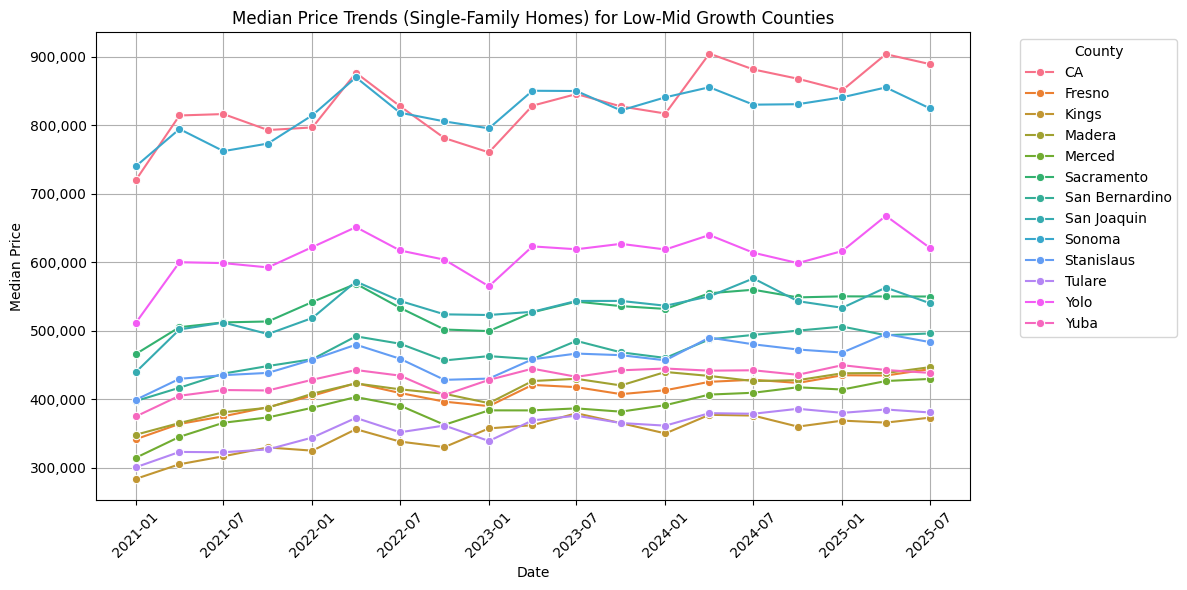

In [258]:
plt.figure(figsize = (12, 6)) # plot median prices overtime
sns.lineplot(data = low_mid_df, x = "Date", y = "MedianPrice", hue = "County", marker = "o")

plt.title("Median Price Trends (Single-Family Homes) for Low-Mid Growth Counties")
plt.xlabel("Date")
plt.ylabel("Median Price")

formatter = FuncFormatter(lambda x, _: f"{int(x):,}")
plt.gca().yaxis.set_major_formatter(formatter)

plt.legend(title = "County", bbox_to_anchor = (1.05, 1), loc = "upper left")

plt.xticks(rotation = 45)
plt.tight_layout()
plt.grid()
plt.show()

In [259]:
# build absolute paths (robust to working-directory differences)
#file_outflow = os.path.join(os.getcwd(), "countyoutflow2122.csv")
#file_inflow = os.path.join(os.getcwd(), "countyinflow2122.csv")

In [260]:
#outflow_df = pd.read_csv("countyoutflow2122.csv")

In [261]:
print(results_df.head(10))

            County  Slope_QuarterNumber  R_squared
0      Santa Clara         22734.590643   0.580800
1           Orange         21135.426901   0.824043
2    Santa Barbara         18731.637427   0.390452
3        San Diego         12663.175439   0.797508
4  San Luis Obispo          9943.766082   0.732361
5      Los Angeles          8754.362573   0.520734
6         Monterey          7605.536842   0.492947
7          Ventura          7368.345029   0.616002
8               CA          6332.046784   0.522727
9       Santa Cruz          6221.929825   0.197505


['Santa Clara', 'Orange', 'Santa Barbara', 'San Diego', 'San Luis Obispo', 'CA']


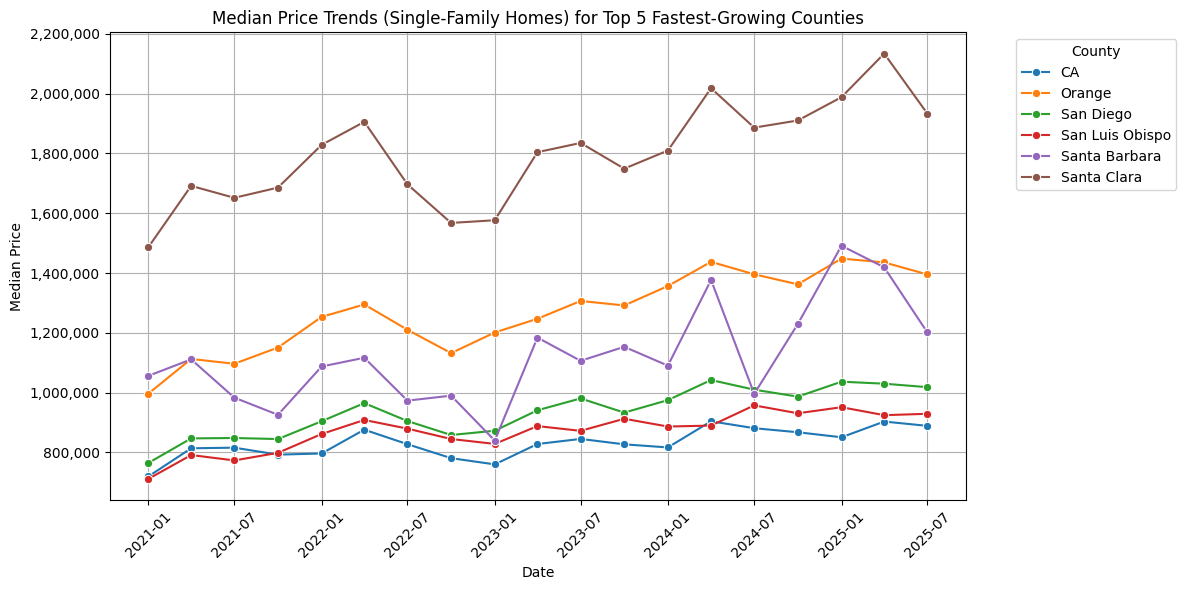

In [262]:
top_counties = results_df.head(5)["County"].tolist()
counties_of_interest = top_counties + ["CA"] # select top counties
print(counties_of_interest)
top_df = car_recent_dfs_master[car_recent_dfs_master["County"].isin(counties_of_interest)].copy() # filter dataframe for the top counties

plt.figure(figsize = (12, 6)) # plot median prices overtime
sns.lineplot(data = top_df, x = "Date", y = "MedianPrice", hue = "County", marker = "o")

plt.title("Median Price Trends (Single-Family Homes) for Top 5 Fastest-Growing Counties")
plt.xlabel("Date")
plt.ylabel("Median Price")

formatter = FuncFormatter(lambda x, _: f"{int(x):,}")
plt.gca().yaxis.set_major_formatter(formatter)

plt.legend(title = "County", bbox_to_anchor = (1.05, 1), loc = "upper left")

plt.xticks(rotation = 45)
plt.tight_layout()
plt.grid()
plt.show()


In [263]:
car_recent_dfs_master["QuarterActual"] = ( (car_recent_dfs_master["QuarterNumber"] - 1) % 4 ) + 1

In [264]:
car_recent_dfs_master["Year"] = car_recent_dfs_master.Date.dt.year

In [265]:
def plot_county_seasonality(df, county, variables=["MedianPrice", "DaysOnMarket", "UII", "HAI"]):

    # filter for selected county
    county_df = df[df["County"] == county]

    # prepare subplots
    fig, axes = plt.subplots(2, 2, figsize = (15, 10))
    axes = axes.flatten()

    # plot heatmap 
    for i, var in enumerate(variables):
        
        # pivot table to get into appropriate format
        pivot_df = county_df.pivot_table(
            index = "Year",
            columns = "QuarterActual",
            values = var
        )
        
        # normalize by row (z-score across quarters)
        pivot_norm = pivot_df.apply(lambda row: (row - row.mean()) / row.std(), axis=1)

        # plot heatmap
        sns.heatmap(
            pivot_norm,
            annot = True,
            cmap = "crest",
            center = 0,
            linewidths = 0.5,
            linecolor = "gray",
            ax = axes[i]
        )
        axes[i].set_title(f"{var} in {county}")
        axes[i].set_xlabel("Quarter")
        axes[i].set_ylabel("Year")

    plt.tight_layout()
    plt.show()


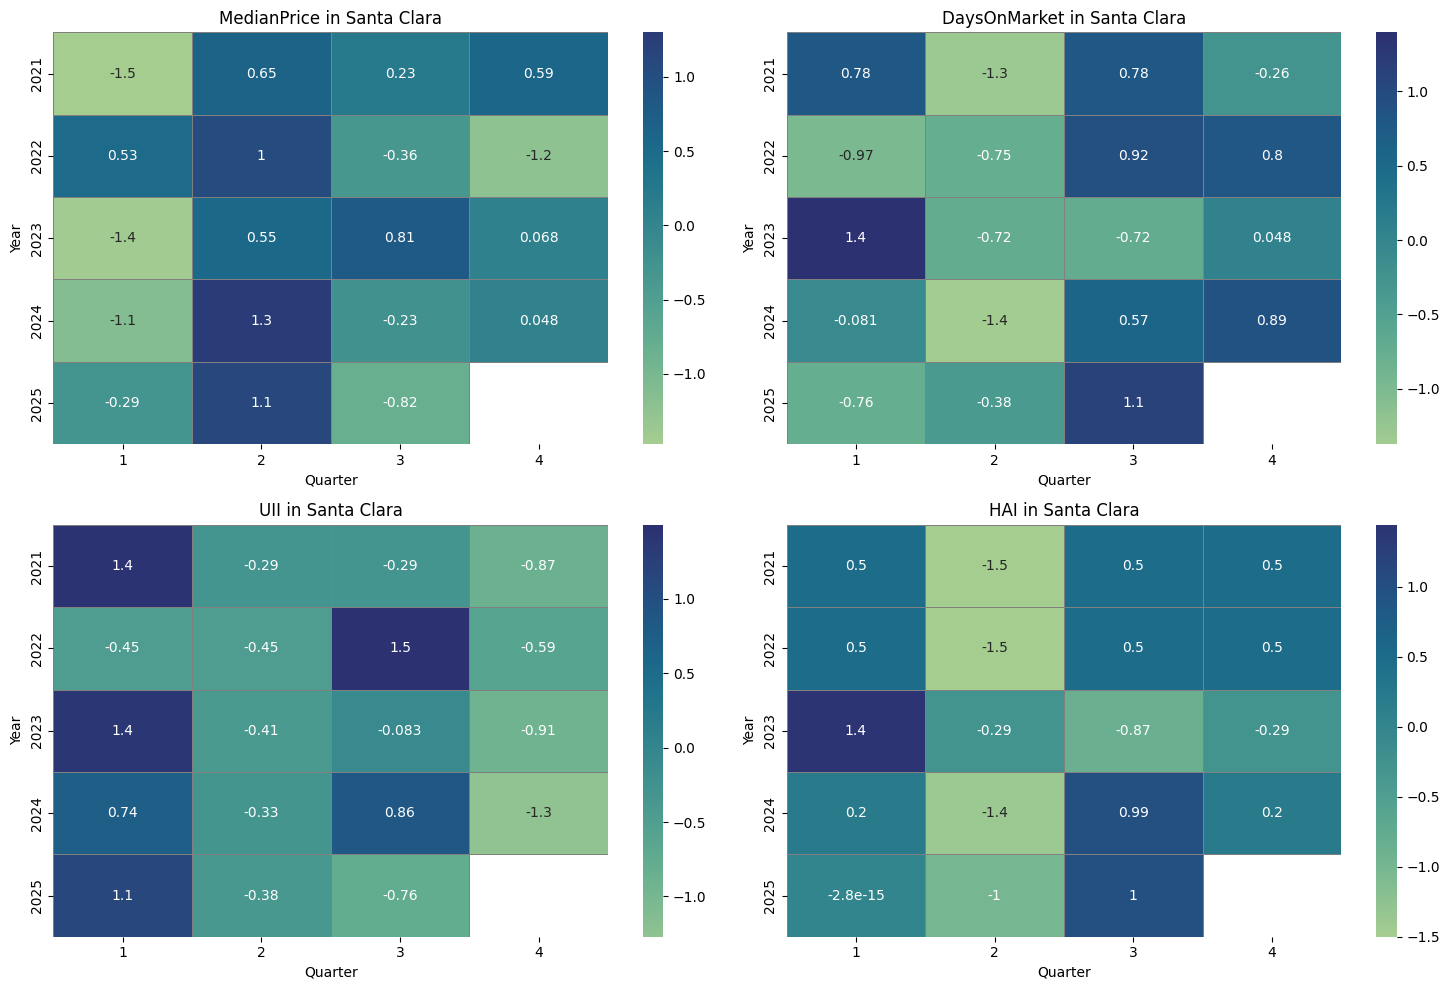

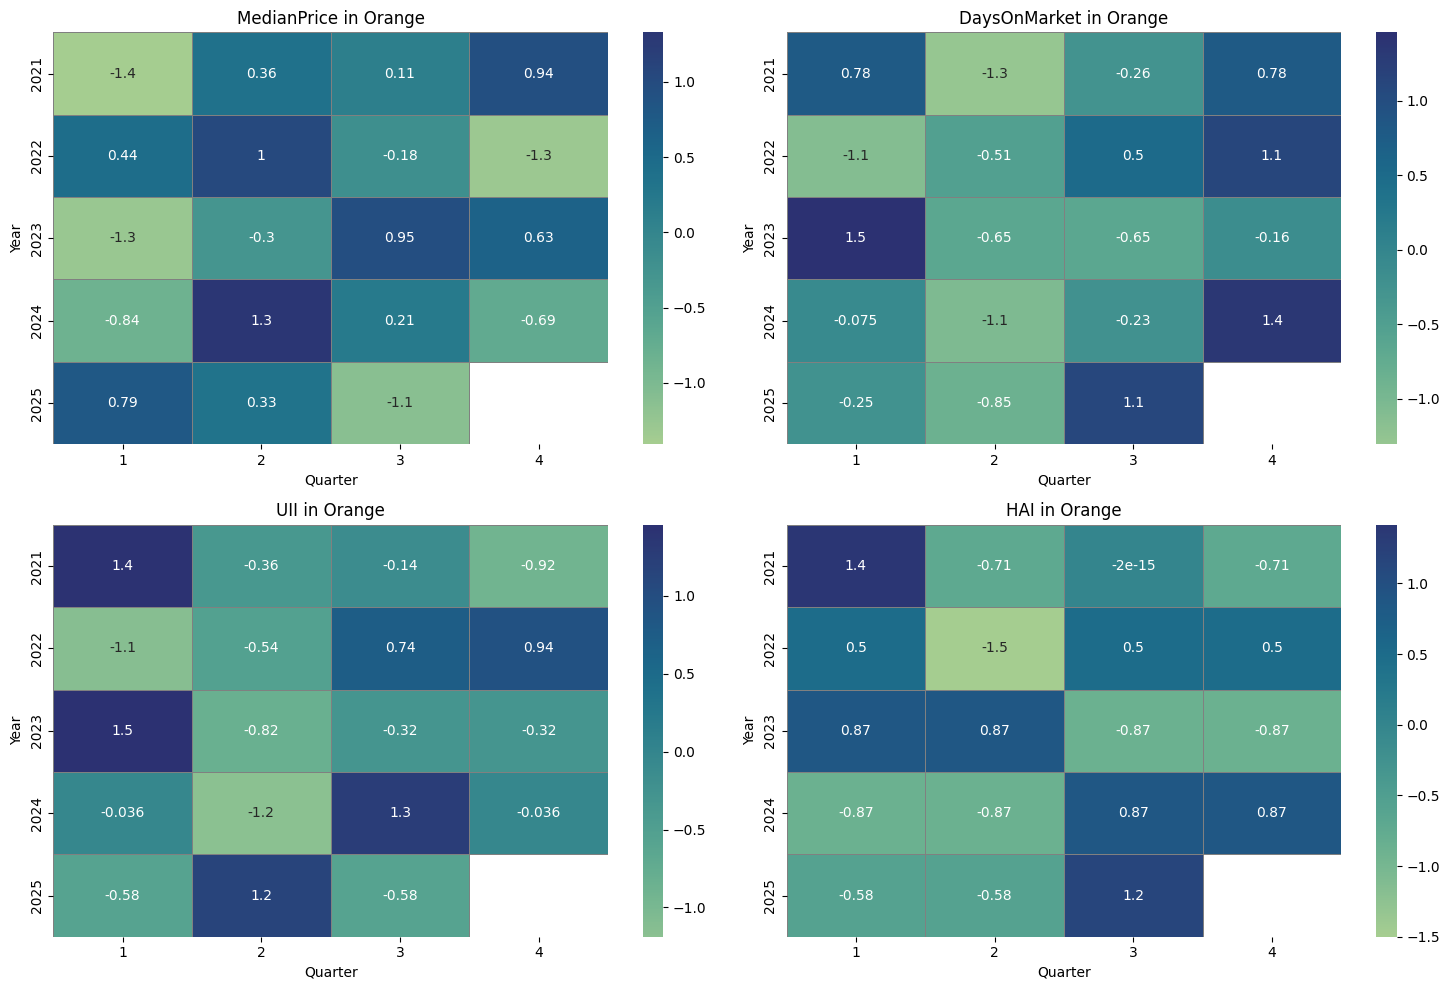

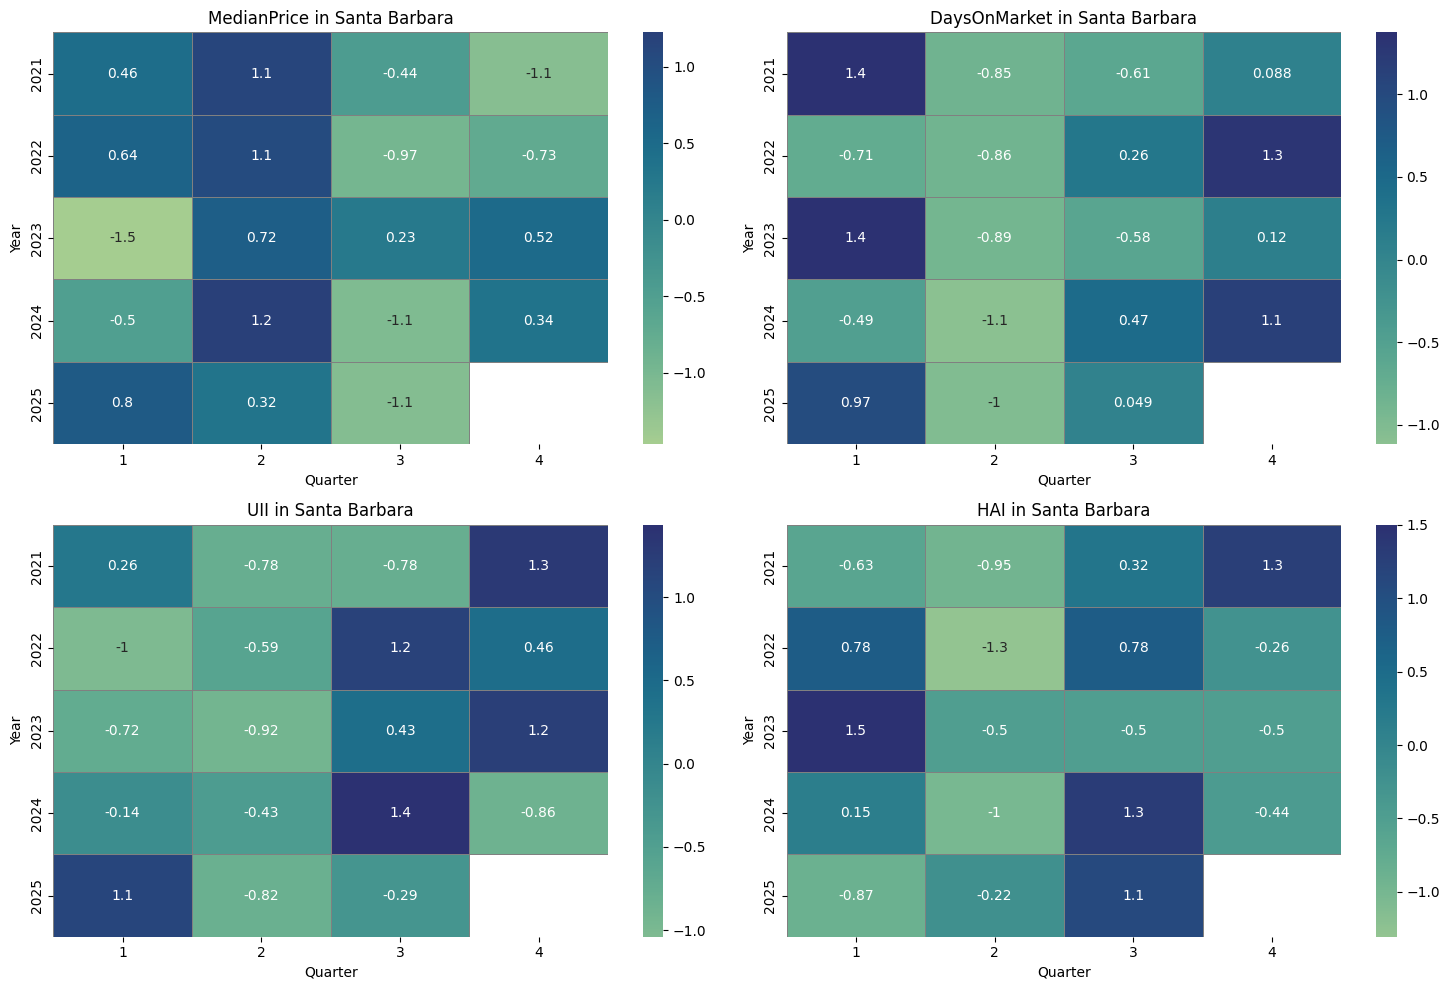

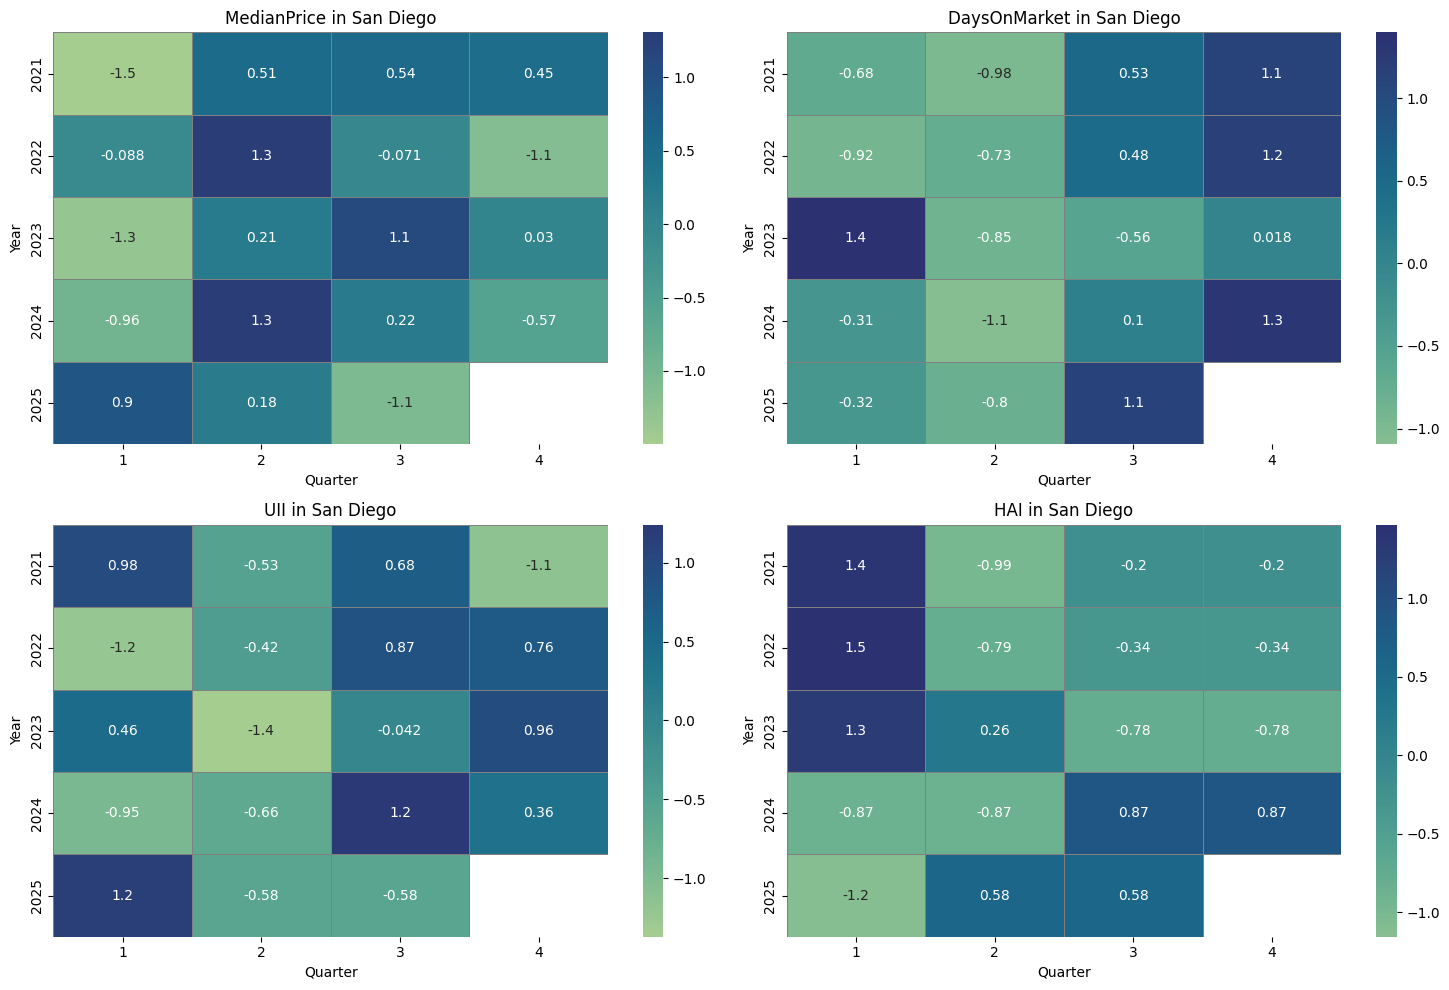

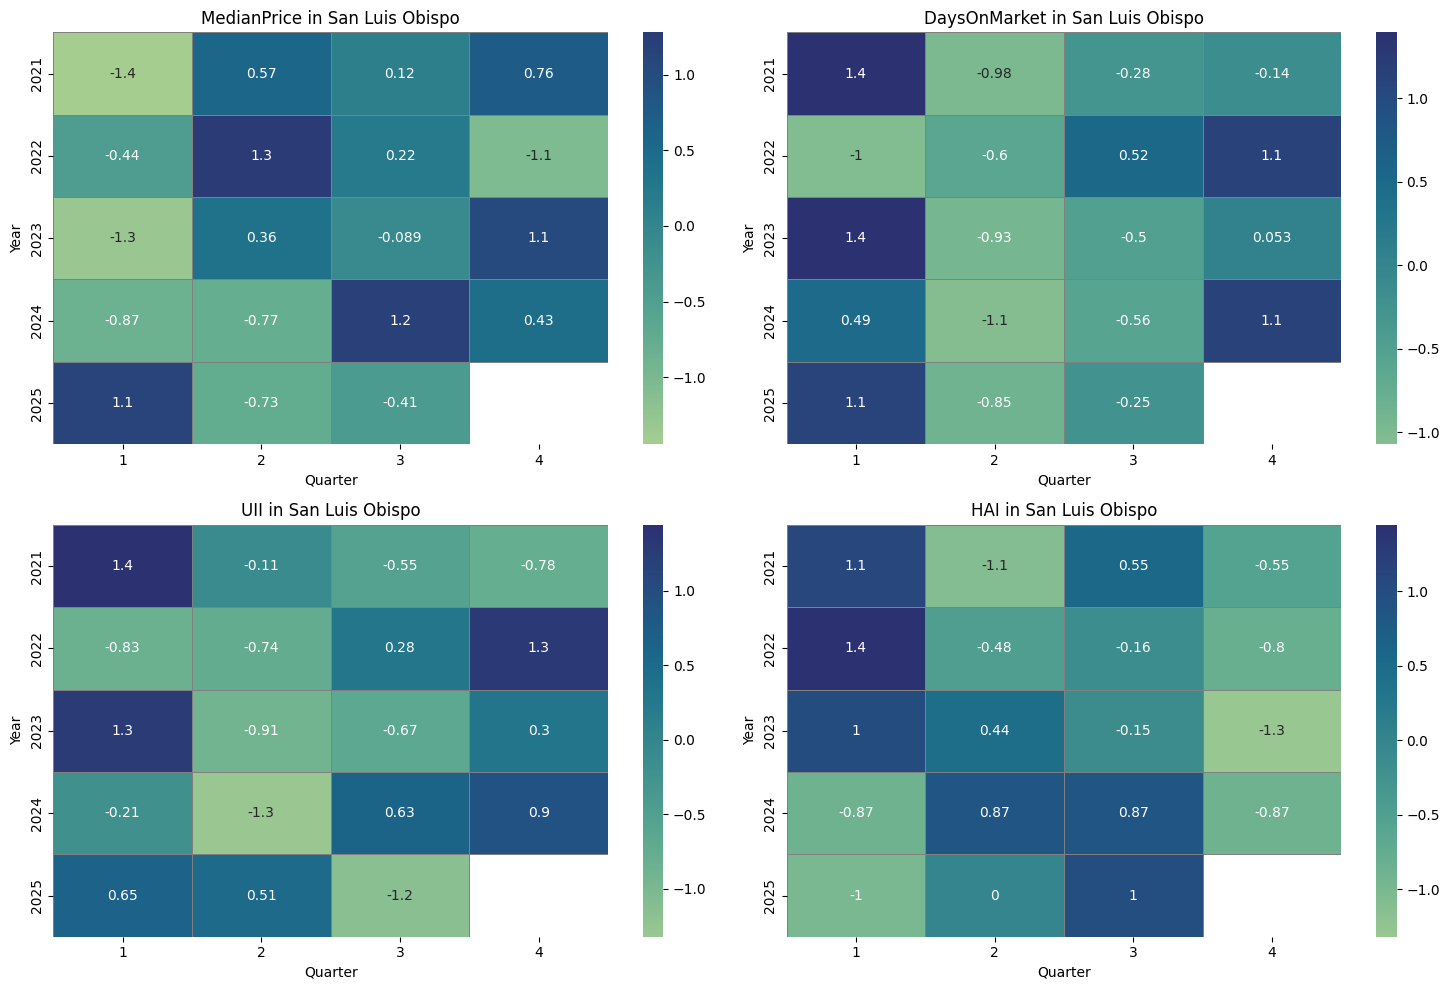

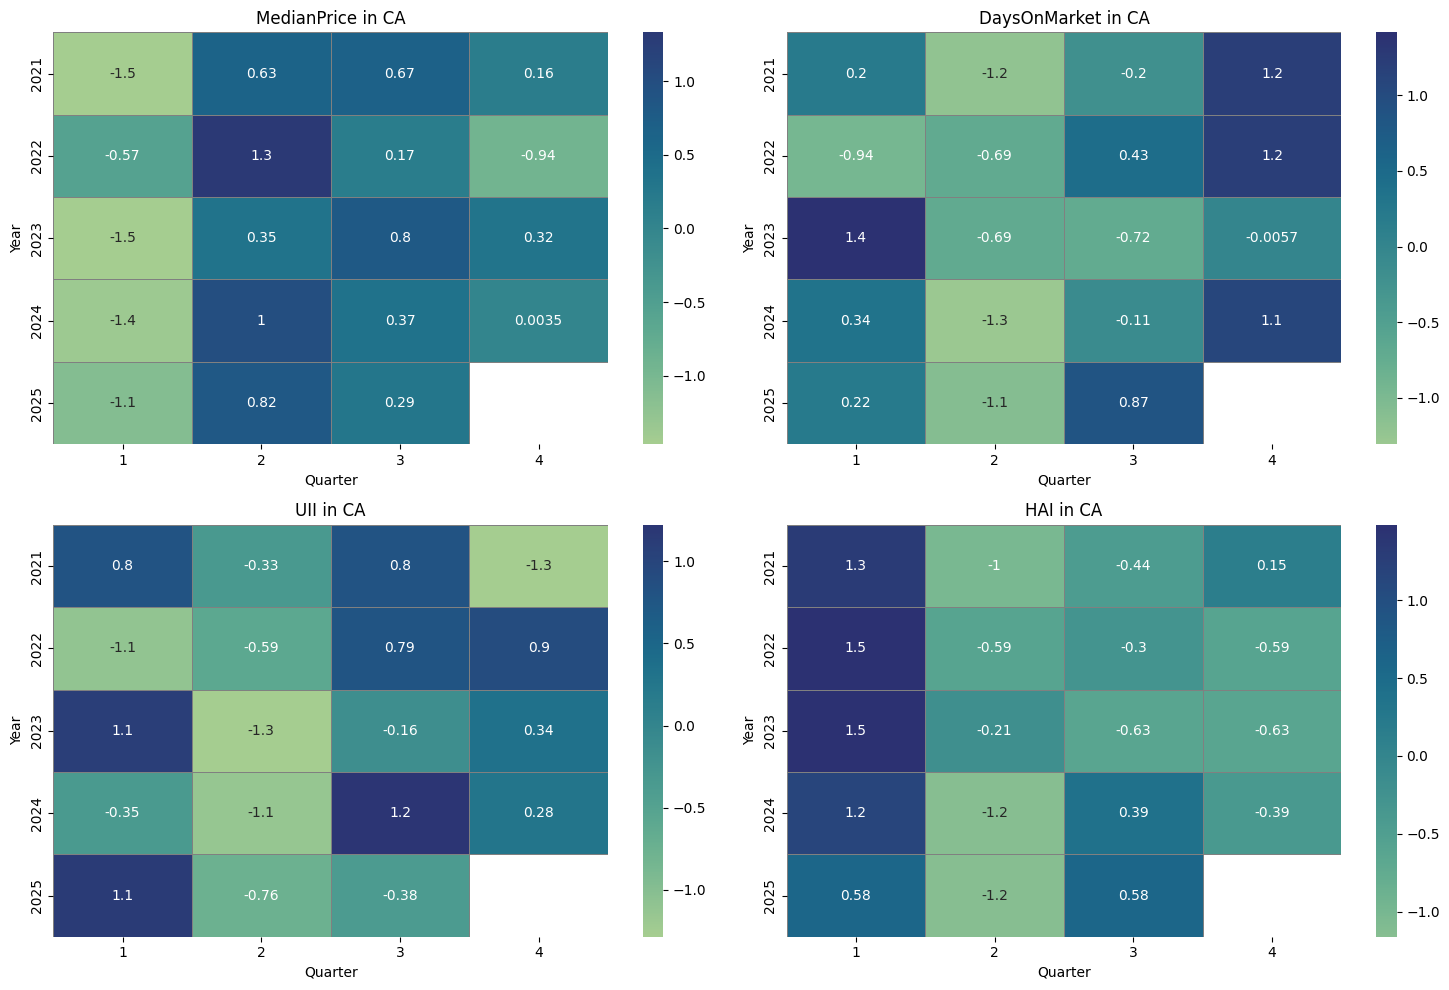

[None, None, None, None, None, None]

In [266]:
[plot_county_seasonality(car_recent_dfs_master, county = county) for county in counties_of_interest]

In [267]:
print(county_migration.tail(10))

    countyfips  year_ending_in  total_inflow  total_agi_in  total_outflow  \
281        113            2018        195210       7524019          97093   
282        113            2019        193016       7965747          97603   
283        113            2020        198765       8324966          98630   
284        113            2021        192849       8720724         102275   
285        113            2022        194152       9804422         106746   
286        115            2018         79817       1745928          33257   
287        115            2019         80167       1856787          33807   
288        115            2020         87426       2048165          35220   
289        115            2021         84656       2223949          37714   
290        115            2022         86648       2419204          39124   

     total_agi_out  net_migration  net_agi  
281        7726148          98117  -202129  
282        8145965          95413  -180218  
283        828825

In [268]:
print(top_counties)

['Santa Clara', 'Orange', 'Santa Barbara', 'San Diego', 'San Luis Obispo']


In [269]:
top_counties_codes = [geocodes[geocodes["CountyName"] == county + " County"]["County Code (FIPS)"].item() for county in top_counties]

In [270]:
def print_migration_table(county_index, county_migration_table = county_migration, top_counties = top_counties, top_counties_codes = top_counties_codes):
    print("County:", top_counties[county_index])
    return county_migration_table[county_migration_table["countyfips"] == top_counties_codes[county_index]]

In [271]:
print(top_counties)

['Santa Clara', 'Orange', 'Santa Barbara', 'San Diego', 'San Luis Obispo']


In [272]:
print_migration_table(0)

County: Santa Clara


,countyfips,year_ending_in,total_inflow,total_agi_in,total_outflow,total_agi_out,net_migration,net_agi
211,085,2018,1895418,156575663,951387,167179563,944031,-10603900
212,085,2019,1886026,169156367,960124,182039613,925902,-12883246
213,085,2020,1866210,163990639,985760,184804181,880450,-20813542
214,085,2021,1754613,184341022,993323,208857627,761290,-24516605
215,085,2022,1786602,237118470,994650,260068960,791952,-22950490


In [273]:
print_migration_table(1)

County: Orange


,countyfips,year_ending_in,total_inflow,total_agi_in,total_outflow,total_agi_out,net_migration,net_agi
146,059,2018,3004036,144956122,1462440,146853704,1541596,-1897582
147,059,2019,2968704,151336970,1468659,152232547,1500045,-895577
148,059,2020,2987761,155732256,1487956,157993801,1499805,-2261545
149,059,2021,2863496,161397305,1532065,169019803,1331431,-7622498
150,059,2022,2902397,196370964,1582841,202936126,1319556,-6565162


In [274]:
print_migration_table(2)

County: Santa Barbara


,countyfips,year_ending_in,total_inflow,total_agi_in,total_outflow,total_agi_out,net_migration,net_agi
206,083,2018,409677,16982176,200129,17253566,209548,-271390
207,083,2019,401166,18001628,199249,18349386,201917,-347758
208,083,2020,405553,19266914,202390,18537069,203163,729845
209,083,2021,385124,21401986,207933,21544831,177191,-142845
210,083,2022,389064,25599635,214313,24527272,174751,1072363


In [275]:
print_migration_table(3)

County: San Diego


,countyfips,year_ending_in,total_inflow,total_agi_in,total_outflow,total_agi_out,net_migration,net_agi
181,073,2018,3121705,129576555,1539363,130602012,1582342,-1025457
182,073,2019,3100785,138344974,1553143,139417763,1547642,-1072789
183,073,2020,3168573,144912732,1580504,145654751,1588069,-742019
184,073,2021,3053995,153431160,1629147,154501121,1424848,-1069961
185,073,2022,3084247,185399068,1668398,187095124,1415849,-1696056


In [276]:
print_migration_table(4)

County: San Luis Obispo


,countyfips,year_ending_in,total_inflow,total_agi_in,total_outflow,total_agi_out,net_migration,net_agi
196,079,2018,256708,10785445,131663,10480739,125045,304706
197,079,2019,252858,11864480,131763,11055406,121095,809074
198,079,2020,259240,12448265,133210,11676929,126030,771336
199,079,2021,253641,12674813,136773,11745089,116868,929724
200,079,2022,252930,15248591,139463,14928039,113467,320552


In [277]:
rows = []

for county_name, county_code in zip(top_counties, top_counties_codes):
    df = county_migration[county_migration["countyfips"] == county_code].copy()
    df.insert(0, "County", county_name)
    rows.append(df)

all_top_counties_df = pd.concat(rows, ignore_index=True)


In [278]:
print(all_top_counties_df)

             County countyfips  year_ending_in  total_inflow  total_agi_in  \
0       Santa Clara        085            2018       1895418     156575663   
1       Santa Clara        085            2019       1886026     169156367   
2       Santa Clara        085            2020       1866210     163990639   
3       Santa Clara        085            2021       1754613     184341022   
4       Santa Clara        085            2022       1786602     237118470   
5            Orange        059            2018       3004036     144956122   
6            Orange        059            2019       2968704     151336970   
7            Orange        059            2020       2987761     155732256   
8            Orange        059            2021       2863496     161397305   
9            Orange        059            2022       2902397     196370964   
10    Santa Barbara        083            2018        409677      16982176   
11    Santa Barbara        083            2019        401166    

In [279]:
# Make sure countyfips is 3-char string (you already did this earlier)
county_migration["countyfips"] = county_migration["countyfips"].astype(str).str.zfill(3)

# Attach CountyName to every row
county_migration_with_names = county_migration.merge(
    geocodes[["County Code (FIPS)", "CountyName"]],
    left_on="countyfips",
    right_on="County Code (FIPS)",
    how="left"
)

# Optional: make a cleaner 'County' column without the " County" suffix
#county_migration_with_names["County"] = (
#    county_migration_with_names["CountyName"].str.removesuffix(" County")
#)


In [280]:
print(county_migration_with_names)

    countyfips  year_ending_in  total_inflow  total_agi_in  total_outflow  \
0          000            2018       4047935     177862197        2467112   
1          000            2018       4047935     177862197        2467112   
2          000            2018       4047935     177862197        2467112   
3          000            2018       4047935     177862197        2467112   
4          000            2018       4047935     177862197        2467112   
..         ...             ...           ...           ...            ...   
768        115            2018         79817       1745928          33257   
769        115            2019         80167       1856787          33807   
770        115            2020         87426       2048165          35220   
771        115            2021         84656       2223949          37714   
772        115            2022         86648       2419204          39124   

     total_agi_out  net_migration   net_agi County Code (FIPS)  \
0        

In [281]:
print(county_migration_with_names["net_migration"].min())
print(county_migration_with_names["net_migration"].max())

147
4156115


In [326]:
print(county_migration_with_names[county_migration_with_names["CountyName"] == "Los Angeles County"])


    countyfips  year_ending_in  total_inflow  total_agi_in  total_outflow  \
573        037            2018       8511752     364977040        4355637   
574        037            2019       8407524     385755789        4384321   
575        037            2020       8367681     382754320        4458817   
576        037            2021       7970499     385075935        4591468   
577        037            2022       8118260     481554496        4660561   

     total_agi_out  net_migration   net_agi County Code (FIPS)  \
573      376803874        4156115 -11826834                037   
574      395861065        4023203 -10105276                037   
575      404608454        3908864 -21854134                037   
576      419479814        3379031 -34403879                037   
577      506595504        3457699 -25041008                037   

             CountyName  
573  Los Angeles County  
574  Los Angeles County  
575  Los Angeles County  
576  Los Angeles County  
577  Los A

In [334]:
print(county_migration_with_names[county_migration_with_names["CountyName"] == "San Francisco County"])


    countyfips  year_ending_in  total_inflow  total_agi_in  total_outflow  \
668        075            2018        816896      81001849         533643   
669        075            2019        813114      91826850         541374   
670        075            2020        773259      85247887         586760   
671        075            2021        730197      86349172         555816   
672        075            2022        746124     123124218         509178   

     total_agi_out  net_migration   net_agi County Code (FIPS)  \
668       86319416         283253  -5317567                075   
669      101751468         271740  -9924618                075   
670      112976505         186499 -27728618                075   
671      117987159         174381 -31637987                075   
672      142515573         236946 -19391355                075   

               CountyName  
668  San Francisco County  
669  San Francisco County  
670  San Francisco County  
671  San Francisco County  


In [327]:
8118260 - 4660561

3457699

In [282]:
"""
geocodes["County Code (FIPS)"] = (
    geocodes["County Code (FIPS)"].astype(str).str.zfill(3)
)
"""

'\ngeocodes["County Code (FIPS)"] = (\n    geocodes["County Code (FIPS)"].astype(str).str.zfill(3)\n)\n'

In [283]:
"""
county_migration_named = county_migration.merge(
    geocodes[["County Code (FIPS)", "CountyName"]],
    left_on="countyfips",
    right_on="County Code (FIPS)",
    how="left"
)

#county_migration_named["County"] = (
#    county_migration_named["CountyName"].str.removesuffix(" County")
#)

county_migration_named = county_migration_named[county_migration_named["CountyName"].str.endswith(" County", na=False)]
county_migration_named["County"] = county_migration_named["CountyName"].str.removesuffix(" County")

county_migration_named = county_migration_named[county_migration_named["year_ending_in"] == 2022]
"""

'\ncounty_migration_named = county_migration.merge(\n    geocodes[["County Code (FIPS)", "CountyName"]],\n    left_on="countyfips",\n    right_on="County Code (FIPS)",\n    how="left"\n)\n\n#county_migration_named["County"] = (\n#    county_migration_named["CountyName"].str.removesuffix(" County")\n#)\n\ncounty_migration_named = county_migration_named[county_migration_named["CountyName"].str.endswith(" County", na=False)]\ncounty_migration_named["County"] = county_migration_named["CountyName"].str.removesuffix(" County")\n\ncounty_migration_named = county_migration_named[county_migration_named["year_ending_in"] == 2022]\n'

In [284]:
#print(county_migration_named)


## Mapping Out Counties

In [285]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

In [286]:
# 1. Read US counties shapefile directly from Census (2023, 1:500k)
url = "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_500k.zip"
counties = gpd.read_file(url)

# 2. Filter to California (STATEFP '06')
ca = counties[counties["STATEFP"] == "06"].copy()

#print(ca[["NAME", "GEOID"]].head())
ca = ca.rename(columns={"NAME": "County"})

ca_merged = ca.merge(results_df, on="County", how = "left")
#print(ca_merged.head(10))
#print(ca_merged.columns)
print(len(ca["County"].unique()))
ca_merged = ca_merged.merge(county_flow_recent, on = "County", how = "left")
ca_merged = ca_merged.merge(county_migration_named, on = "County", how = "left")
ca_merged["net_agi_millions"] = ca_merged["net_agi"] / 1e6


58


In [287]:
print(ca_merged["County"].unique())

['Los Angeles' 'Santa Cruz' 'Sonoma' 'Contra Costa' 'Alpine' 'Nevada'
 'Butte' 'Shasta' 'Merced' 'Calaveras' 'Lake' 'Yuba' 'San Diego'
 'Riverside' 'Marin' 'San Mateo' 'El Dorado' 'Tulare' 'Sacramento'
 'San Benito' 'Amador' 'Sutter' 'Yolo' 'Colusa' 'Plumas' 'Stanislaus'
 'Trinity' 'San Bernardino' 'Alameda' 'Mono' 'Monterey' 'Inyo'
 'Santa Clara' 'Humboldt' 'Sierra' 'Madera' 'San Joaquin' 'Fresno'
 'Ventura' 'Siskiyou' 'Mendocino' 'Glenn' 'Del Norte' 'Imperial' 'Placer'
 'Mariposa' 'Napa' 'Santa Barbara' 'Tuolumne' 'Orange' 'San Luis Obispo'
 'Solano' 'Modoc' 'Kern' 'Kings' 'Tehama' 'Lassen' 'San Francisco']


In [288]:
print(county_flow_recent["County"].unique())

['Alameda' 'Alpine' 'Amador' 'Butte' 'Calaveras' 'Colusa' 'Contra Costa'
 'Del Norte' 'El Dorado' 'Fresno' 'Glenn' 'Humboldt' 'Imperial' 'Inyo'
 'Kern' 'Kings' 'Lake' 'Lassen' 'Los Angeles' 'Madera' 'Marin' 'Mariposa'
 'Mendocino' 'Merced' 'Modoc' 'Mono' 'Monterey' 'Napa' 'Nevada' 'Orange'
 'Placer' 'Plumas' 'Riverside' 'Sacramento' 'San Benito' 'San Bernardino'
 'San Diego' 'San Francisco' 'San Joaquin' 'San Luis Obispo' 'San Mateo'
 'Santa Barbara' 'Santa Clara' 'Santa Cruz' 'Shasta' 'Sierra' 'Siskiyou'
 'Solano' 'Sonoma' 'Stanislaus' 'Sutter' 'Tehama' 'Trinity' 'Tulare'
 'Tuolumne' 'Ventura' 'Yolo' 'Yuba']


In [289]:
print(len(results_df["County"].unique()))

52


In [290]:
print(len(ca_merged["County"].unique()))

58


In [ ]:
#ca_merged.to_csv("ca_merged", index = False)

## Map of Price Growth Rates

In [291]:
# Dark green → white → dark red
colors = ["#006400", "white", "#8b0000"]   # darkgreen → white → darkred
custom_cmap = LinearSegmentedColormap.from_list("green_white_red", colors)

In [292]:
# Identify min/max of your numeric variable
vmin = ca_merged["Slope_QuarterNumber"].min()
vmax = ca_merged["Slope_QuarterNumber"].max()

# Center the scale at 0
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

In [293]:
print(ca_merged["Slope_QuarterNumber"])

0      8754.362573
1      6221.929825
2      4056.932164
3              NaN
4              NaN
5       462.865497
6      1256.070175
7      1068.842105
8      4307.269006
9       388.298246
10       47.719298
11     2519.350877
12    12663.175439
13     4483.807018
14      684.502924
15     6033.333333
16     2362.567251
17     3940.957895
18     3034.765497
19     1287.742690
20     1097.163743
21     2337.561404
22     2984.982456
23             NaN
24     1516.233918
25     3455.269006
26    -2451.040936
27     4268.485380
28     1910.877193
29    -3963.730994
30     7605.536842
31             NaN
32    22734.590643
33     1305.918129
34             NaN
35     4177.964912
36     3633.649123
37     4037.245614
38     7368.345029
39      439.011696
40    -2922.269006
41     1963.426901
42      586.947368
43     5919.184795
44     1166.736842
45             NaN
46     1423.988304
47    18731.637427
48     1545.128655
49    21135.426901
50     9943.766082
51     1355.040936
52          

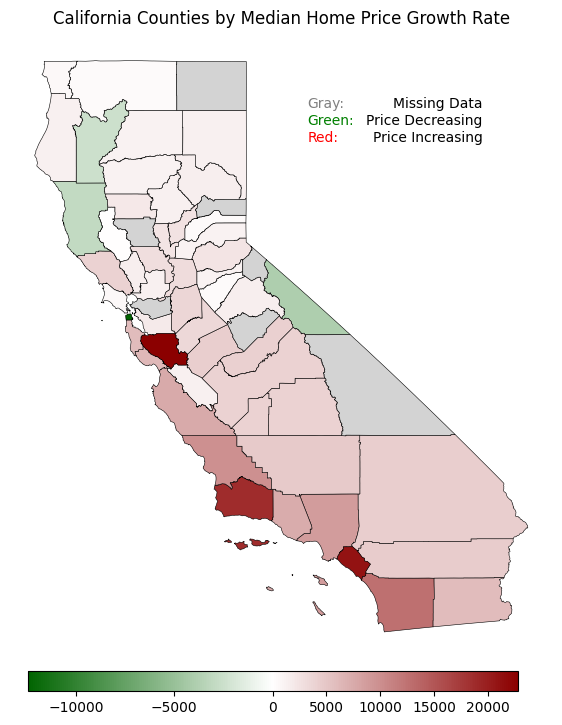

In [294]:
fig, ax = plt.subplots(figsize=(7, 10))

ca_merged.plot(
    column="Slope_QuarterNumber",
    cmap=custom_cmap,
    norm=norm,
    linewidth=0.4,
    edgecolor="black",
    #legend=True,
    ax=ax,
    
    # ⬅️ NEW: style NaN counties in gray
    missing_kwds={
        "color": "lightgray",   # fill color for missing data
        #"edgecolor": "black",
        #"hatch": "///",
        "label": "Missing Data"
    }
)    

plt.figtext(
    0.55, 0.717,                     # position (centered, slightly below the figure)
    "Gray:\n",#Green:\nRed",         # caption text
    ha="left", fontsize=10, color = "gray"
)

plt.figtext(
    0.55, 0.683,                     # position (centered, slightly below the figure)
    "Red:\n",#Green:\nRed",         # caption text
    ha="left", fontsize=10, color = "red"
)

plt.figtext(
    0.55, 0.7,                     # position (centered, slightly below the figure)
    "Green:\n",#Green:\nRed",         # caption text
    ha="left", fontsize=10, color = "green"
)
"""
plt.figtext(
    0.8, 0.7,                     # position (centered, slightly below the figure)
    "Missing Data\nDecreasing Price\nIncreasing Price",         # caption text
    ha="right", fontsize=10
)
"""
plt.figtext(
    0.8, 0.717,                     # position (centered, slightly below the figure)
    "Missing Data\n",#Green:\nRed",         # caption text
    ha="right", fontsize=10
)

plt.figtext(
    0.8, 0.683,                     # position (centered, slightly below the figure)
    "Price Increasing\n",#Green:\nRed",         # caption text
    ha="right", fontsize=10
)

plt.figtext(
    0.8, 0.7,                     # position (centered, slightly below the figure)
    "Price Decreasing\n",#Green:\nRed",         # caption text
    ha="right", fontsize=10
)

# ---- Shrink colorbar size ----
# Create a custom axis (x0, y0, width, height) in figure coordinates
cax = fig.add_axes([0.15, 0.15, 0.7, 0.02])  # adjust width & height

# Draw the colorbar into the smaller axis
sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
sm.set_array([])

fig.colorbar(sm, cax=cax, orientation="horizontal")

ax.set_axis_off()
ax.set_title("California Counties by Median Home Price Growth Rate", fontsize=12)
plt.show()


In [295]:
"""
# Example numeric variable per county
np.random.seed(1)
data = pd.DataFrame({
    "NAME": ca["NAME"],
    "value": np.random.rand(len(ca))
})

ca_merged = ca.merge(data, on="NAME")

fig, ax = plt.subplots(figsize=(6, 8))
ca_merged.plot(
    column="value",
    ax=ax,
    edgecolor="black",
    linewidth=0.5,
    legend=True
)
ax.set_axis_off()
ax.set_title("California Counties (colored by value)")
plt.show()
"""

'\n# Example numeric variable per county\nnp.random.seed(1)\ndata = pd.DataFrame({\n    "NAME": ca["NAME"],\n    "value": np.random.rand(len(ca))\n})\n\nca_merged = ca.merge(data, on="NAME")\n\nfig, ax = plt.subplots(figsize=(6, 8))\nca_merged.plot(\n    column="value",\n    ax=ax,\n    edgecolor="black",\n    linewidth=0.5,\n    legend=True\n)\nax.set_axis_off()\nax.set_title("California Counties (colored by value)")\nplt.show()\n'

## Map of Net Income Flow (most recent year)

In [340]:
# Dark green → white → dark red
colors = ["#8b0000", "white", "#006400"]   # darkgreen → white → darkred
custom_cmap = LinearSegmentedColormap.from_list("green_white_red", colors)

In [297]:
print(ca_merged.columns)

Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOIDFQ', 'GEOID', 'County',
       'NAMELSAD', 'STUSPS', 'STATE_NAME', 'LSAD', 'ALAND', 'AWATER',
       'geometry', 'Slope_QuarterNumber', 'R_squared', 'county_fips', 'year',
       'workers_living', 'jobs_located', 'net_inflow', 'County Code (FIPS)_x',
       'countyfips', 'year_ending_in', 'total_inflow', 'total_agi_in',
       'total_outflow', 'total_agi_out', 'net_migration', 'net_agi',
       'County Code (FIPS)_y', 'CountyName', 'net_agi_millions'],
      dtype='object')


In [298]:
"""
# Identify min/max of your numeric variable
vmin = ca_merged["net_agi_millions"].min()
vmax = ca_merged["net_agi_millions"].max()

# Center the scale at 0
norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
"""

'\n# Identify min/max of your numeric variable\nvmin = ca_merged["net_agi_millions"].min()\nvmax = ca_merged["net_agi_millions"].max()\n\n# Center the scale at 0\nnorm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)\n'

In [341]:
# after you create ca_merged["net_agi_millions"]
vmin = ca_merged["net_agi_millions"].min()   # ≈ -25.041008
vmax = ca_merged["net_agi_millions"].max()   # ≈  2.399817

# Make symmetric limits around 0
limit = max(abs(vmin), abs(vmax))    # ≈ 25.041008

norm = TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)

In [342]:
print(vmin, vmax)

-25.041008 2.399817


In [343]:
print(ca_merged[["net_agi_millions","County"]])

    net_agi_millions           County
0         -25.041008      Los Angeles
1          -0.269753       Santa Cruz
2           0.012866           Sonoma
3          -2.307148     Contra Costa
4          -0.023867           Alpine
5           0.022758           Nevada
6          -0.169655            Butte
7          -0.042122           Shasta
8          -0.029965           Merced
9           0.110598        Calaveras
10         -0.050349             Lake
11          0.051289             Yuba
12         -1.696056        San Diego
13          2.399817        Riverside
14          0.455923            Marin
15        -10.310334        San Mateo
16          0.131201        El Dorado
17         -0.418130           Tulare
18         -1.461114       Sacramento
19          0.219208       San Benito
20          0.192695           Amador
21         -0.158353           Sutter
22         -0.383462             Yolo
23         -0.010844           Colusa
24         -0.065681           Plumas
25         -

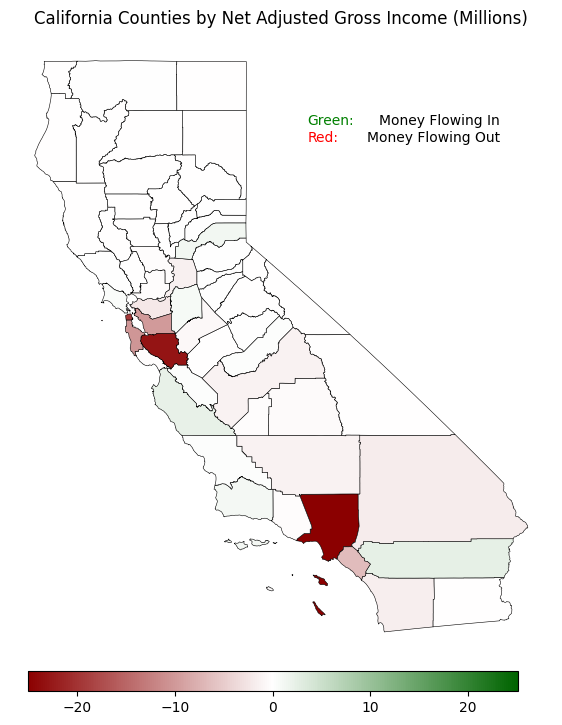

In [344]:
fig, ax = plt.subplots(figsize=(7, 10))


ca_merged.plot(
    column="net_agi_millions",
    cmap=custom_cmap,
    norm=norm,
    linewidth=0.4,
    edgecolor="black",
    ax=ax,
    missing_kwds={"color": "lightgray", "label": "Missing Data"}
)
"""
ca_merged.plot(
    column="net_agi_millions",
    cmap=custom_cmap,
    norm=norm,
    linewidth=0.4,
    edgecolor="black",
    #legend=True,
    ax=ax,
    
    # ⬅️ NEW: style NaN counties in gray
    missing_kwds={
        "color": "lightgray",   # fill color for missing data
        #"edgecolor": "black",
        #"hatch": "///",
        "label": "Missing Data"
    }
) 
"""   
"""
plt.figtext(
    0.55, 0.717,                     # position (centered, slightly below the figure)
    "Gray:\n",#Green:\nRed",         # caption text
    ha="left", fontsize=10, color = "gray"
)
"""

plt.figtext(
    0.55, 0.683,                     # position (centered, slightly below the figure)
    "Red:\n",#Green:\nRed",         # caption text
    ha="left", fontsize=10, color = "red"
)

plt.figtext(
    0.55, 0.7,                     # position (centered, slightly below the figure)
    "Green:\n",#Green:\nRed",         # caption text
    ha="left", fontsize=10, color = "green"
)
"""
plt.figtext(
    0.8, 0.7,                     # position (centered, slightly below the figure)
    "Missing Data\nDecreasing Price\nIncreasing Price",         # caption text
    ha="right", fontsize=10
)
"""

"""
plt.figtext(
    0.8, 0.717,                     # position (centered, slightly below the figure)
    "Missing Data\n",#Green:\nRed",         # caption text
    ha="right", fontsize=10
)
"""

plt.figtext(
    0.825, 0.683,                     # position (centered, slightly below the figure)
    "Money Flowing Out\n",            # caption text
    ha="right", fontsize=10
)

plt.figtext(
    0.825, 0.7,                     # position (centered, slightly below the figure)
    "Money Flowing In\n",          # caption text
    ha="right", fontsize=10
)

# ---- Shrink colorbar size ----
# Create a custom axis (x0, y0, width, height) in figure coordinates
cax = fig.add_axes([0.15, 0.15, 0.7, 0.02])  # adjust width & height

# Draw the colorbar into the smaller axis
sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
sm.set_array([])

fig.colorbar(sm, cax=cax, orientation="horizontal")

ax.set_axis_off()
ax.set_title("California Counties by Net Adjusted Gross Income (Millions)", fontsize=12)
plt.show()

In [303]:
top10 = ca_merged.sort_values("net_agi_millions", ascending=True).head(10)
table = tabulate(top10[["County", "net_agi_millions"]], headers="keys", tablefmt="pretty")

print(table)

+----+----------------+------------------+
|    |     County     | net_agi_millions |
+----+----------------+------------------+
| 0  |  Los Angeles   |    -25.041008    |
| 32 |  Santa Clara   |    -22.95049     |
| 57 | San Francisco  |    -19.391355    |
| 15 |   San Mateo    |    -10.310334    |
| 28 |    Alameda     |    -9.912457     |
| 49 |     Orange     |    -6.565162     |
| 3  |  Contra Costa  |    -2.307148     |
| 27 | San Bernardino |     -1.83765     |
| 12 |   San Diego    |    -1.696056     |
| 18 |   Sacramento   |    -1.461114     |
+----+----------------+------------------+


In [304]:
top10 = ca_merged.sort_values("net_agi_millions", ascending=False).head(10)
table = tabulate(top10[["County", "net_agi_millions"]], headers="keys", tablefmt="pretty")

print(table)

+----+-----------------+------------------+
|    |     County      | net_agi_millions |
+----+-----------------+------------------+
| 13 |    Riverside    |     2.399817     |
| 30 |    Monterey     |     2.289843     |
| 44 |     Placer      |     1.210011     |
| 47 |  Santa Barbara  |     1.072363     |
| 36 |   San Joaquin   |     0.789168     |
| 14 |      Marin      |     0.455923     |
| 50 | San Luis Obispo |     0.320552     |
| 35 |     Madera      |     0.229271     |
| 19 |   San Benito    |     0.219208     |
| 20 |     Amador      |     0.192695     |
+----+-----------------+------------------+


In [305]:
top10 = ca_merged.sort_values("net_agi_millions", ascending=False)
table = tabulate(top10[["County", "net_agi_millions"]], headers="keys", tablefmt="pretty")

print(table)

+----+-----------------+------------------+
|    |     County      | net_agi_millions |
+----+-----------------+------------------+
| 13 |    Riverside    |     2.399817     |
| 30 |    Monterey     |     2.289843     |
| 44 |     Placer      |     1.210011     |
| 47 |  Santa Barbara  |     1.072363     |
| 36 |   San Joaquin   |     0.789168     |
| 14 |      Marin      |     0.455923     |
| 50 | San Luis Obispo |     0.320552     |
| 35 |     Madera      |     0.229271     |
| 19 |   San Benito    |     0.219208     |
| 20 |     Amador      |     0.192695     |
| 16 |    El Dorado    |     0.131201     |
| 9  |    Calaveras    |     0.110598     |
| 11 |      Yuba       |     0.051289     |
| 5  |     Nevada      |     0.022758     |
| 2  |     Sonoma      |     0.012866     |
| 39 |    Siskiyou     |     0.004611     |
| 45 |    Mariposa     |     0.001667     |
| 34 |     Sierra      |     0.000783     |
| 42 |    Del Norte    |    -0.001092     |
| 23 |     Colusa      |    -0.0

## Map of Net Migration

In [314]:
# Dark green → white → dark red
colors = ["white", "#006400"]   # darkgreen → white → darkred
custom_cmap = LinearSegmentedColormap.from_list("green_white_red", colors)

In [319]:
# after you create ca_merged["net_agi_millions"]
vmin = (ca_merged["net_migration"]/100000).min()   
vmax = (ca_merged["net_migration"]/100000).max()   

norm = TwoSlopeNorm(vmin=vmin, vcenter=(vmin + vmax) / 2, vmax=vmax)

In [307]:
print(ca_merged[["net_migration","County"]])

    net_migration           County
0         3457699      Los Angeles
1          100736       Santa Cruz
2          200050           Sonoma
3          537249     Contra Costa
4             147           Alpine
5           44200           Nevada
6           80129            Butte
7           76124           Shasta
8          142860           Merced
9           22435        Calaveras
10          25642             Lake
11          47524             Yuba
12        1415849        San Diego
13        1193536        Riverside
14         106153            Marin
15         310865        San Mateo
16          93452        El Dorado
17         222701           Tulare
18         663504       Sacramento
19          37114       San Benito
20          18708           Amador
21          46801           Sutter
22          87406             Yolo
23          11455           Colusa
24           6956           Plumas
25         256667       Stanislaus
26           3794          Trinity
27        1014918   

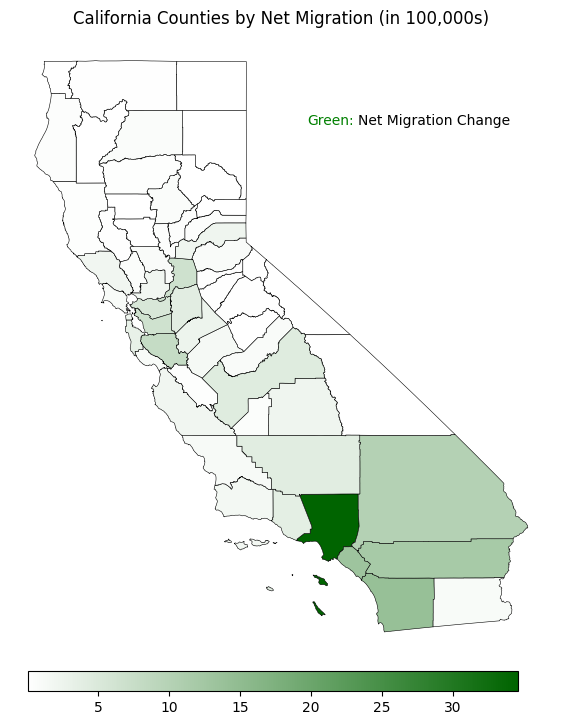

In [331]:
fig, ax = plt.subplots(figsize=(7, 10))


ca_merged.plot(
    column=(ca_merged["net_migration"] / 100000),
    cmap=custom_cmap,
    norm=norm,
    linewidth=0.4,
    edgecolor="black",
    ax=ax,
    missing_kwds={"color": "lightgray", "label": "Missing Data"}
)
"""
ca_merged.plot(
    column="net_agi_millions",
    cmap=custom_cmap,
    norm=norm,
    linewidth=0.4,
    edgecolor="black",
    #legend=True,
    ax=ax,
    
    # ⬅️ NEW: style NaN counties in gray
    missing_kwds={
        "color": "lightgray",   # fill color for missing data
        #"edgecolor": "black",
        #"hatch": "///",
        "label": "Missing Data"
    }
) 
"""   
"""
plt.figtext(
    0.55, 0.717,                     # position (centered, slightly below the figure)
    "Gray:\n",#Green:\nRed",         # caption text
    ha="left", fontsize=10, color = "gray"
)
"""
"""
plt.figtext(
    0.55, 0.683,                     # position (centered, slightly below the figure)
    "Red:\n",#Green:\nRed",         # caption text
    ha="left", fontsize=10, color = "red"
)
"""

plt.figtext(
    0.55, 0.7,                     # position (centered, slightly below the figure)
    "Green:\n",#Green:\nRed",         # caption text
    ha="left", fontsize=10, color = "green"
)


"""
plt.figtext(
    0.8, 0.7,                     # position (centered, slightly below the figure)
    "Missing Data\nDecreasing Price\nIncreasing Price",         # caption text
    ha="right", fontsize=10
)
"""

"""
plt.figtext(
    0.8, 0.717,                     # position (centered, slightly below the figure)
    "Missing Data\n",#Green:\nRed",         # caption text
    ha="right", fontsize=10
)
"""
"""
plt.figtext(
    0.825, 0.683,                     # position (centered, slightly below the figure)
    "Money Flowing Out\n",            # caption text
    ha="right", fontsize=10
)
"""

plt.figtext(
    0.84, 0.7,                     # position (centered, slightly below the figure)
    "Net Migration Change\n",          # caption text
    ha="right", fontsize=10
)

# ---- Shrink colorbar size ----
# Create a custom axis (x0, y0, width, height) in figure coordinates
cax = fig.add_axes([0.15, 0.15, 0.7, 0.02])  # adjust width & height

# Draw the colorbar into the smaller axis
sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
sm.set_array([])

fig.colorbar(sm, cax=cax, orientation="horizontal")

ax.set_axis_off()
ax.set_title("California Counties by Net Migration (in 100,000s)", fontsize=12)
plt.show()

In [333]:
top10 = ca_merged.sort_values("net_migration", ascending=False)


# Take only the first 10 rows *before* tabulating
top10_small = top10[["County", "net_migration"]].head(10)

table = tabulate(top10_small, headers="keys", tablefmt="pretty")
print(table)

+----+----------------+---------------+
|    |     County     | net_migration |
+----+----------------+---------------+
| 0  |  Los Angeles   |    3457699    |
| 12 |   San Diego    |    1415849    |
| 49 |     Orange     |    1319556    |
| 13 |   Riverside    |    1193536    |
| 27 | San Bernardino |    1014918    |
| 32 |  Santa Clara   |    791952     |
| 18 |   Sacramento   |    663504     |
| 28 |    Alameda     |    657107     |
| 3  |  Contra Costa  |    537249     |
| 37 |     Fresno     |    445781     |
+----+----------------+---------------+
